In [52]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [53]:
!pip install -q segmentation-models-pytorch
!pip install -q albumentations
!pip install -q torchmetrics
!pip install -q opencv-python
!pip install -q tqdm

In [54]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torchvision

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from tqdm import tqdm

In [55]:
!git clone https://github.com/alexgkendall/SegNet-Tutorial.git

fatal: destination path 'SegNet-Tutorial' already exists and is not an empty directory.


In [56]:
import os

base = "SegNet-Tutorial/CamVid"

print("Train Images :", len(os.listdir(base + "/train")))
print("Train Masks  :", len(os.listdir(base + "/trainannot")))

print("Validation Images :", len(os.listdir(base + "/val")))
print("Validation Masks  :", len(os.listdir(base + "/valannot")))

print("Test Images :", len(os.listdir(base + "/test")))
print("Test Masks  :", len(os.listdir(base + "/testannot")))

Train Images : 367
Train Masks  : 367
Validation Images : 101
Validation Masks  : 101
Test Images : 233
Test Masks  : 233


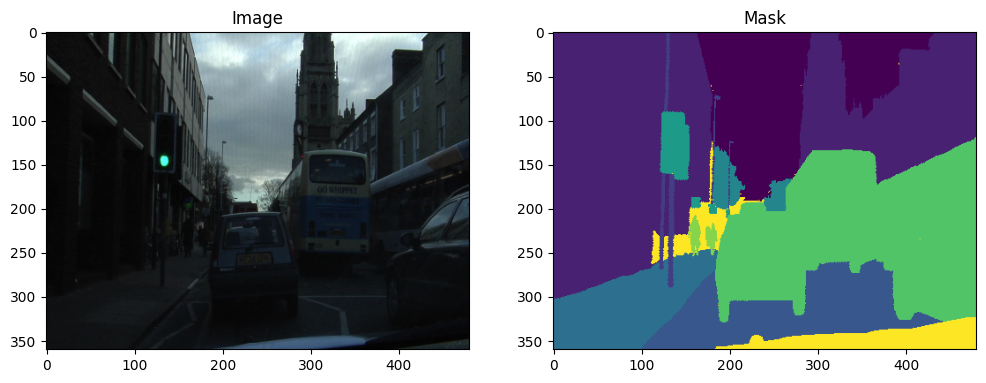

In [57]:
import os
from PIL import Image
import matplotlib.pyplot as plt

base = "SegNet-Tutorial/CamVid"

img_name = sorted(os.listdir(base + "/train"))[0]

image = Image.open(os.path.join(base, "train", img_name))
mask = Image.open(os.path.join(base, "trainannot", img_name))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(image)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask)
plt.title("Mask")

plt.show()

In [58]:
print(image.size)
print(mask.size)

(480, 360)
(480, 360)


In [59]:
import numpy as np

mask_np = np.array(mask)

print(mask_np.shape)
print(np.unique(mask_np)[:20])

(360, 480)
[ 0  1  2  3  4  5  6  8  9 11]


In [60]:
class CamVidDataset(Dataset):
    def __init__(self, root, split="train", transforms=None):
        self.root = root
        self.split = split
        self.transforms = transforms

        self.images_dir = os.path.join(root, split)
        self.masks_dir = os.path.join(root, split + "annot")

        self.images = sorted(os.listdir(self.images_dir))
        self.masks = sorted(os.listdir(self.masks_dir))

        # Safety check
        assert len(self.images) == len(self.masks), "Images and masks count mismatch"

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        img_path = os.path.join(self.images_dir, self.images[idx])
        mask_path = os.path.join(self.masks_dir, self.masks[idx])

        image = Image.open(img_path).convert("RGB")
        mask = np.array(Image.open(mask_path))

        if self.transforms:
            augmented = self.transforms(
                image=np.array(image),
                mask=mask
            )
            image = augmented["image"]
            mask = augmented["mask"]

        # CrossEntropyLoss expects LongTensor targets
        mask = torch.as_tensor(mask, dtype=torch.long)

        return image, mask

In [61]:
train_transform = A.Compose([

    A.RandomCrop(320,320),

    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(

        shift_limit=0.05,

        scale_limit=0.10,

        rotate_limit=10,

        border_mode=0,

        p=0.5
    ),

    A.RandomBrightnessContrast(p=0.5),

    A.HueSaturationValue(p=0.3),

    A.GaussNoise(p=0.2),

    A.Resize(360,480),

    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),

    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(360, 480),
    A.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225)
    ),
    ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [62]:
ROOT = "SegNet-Tutorial/CamVid"
train_dataset = CamVidDataset(
    root=ROOT,
    split="train",
    transforms=train_transform
)

val_dataset = CamVidDataset(
    root=ROOT,
    split="val",
    transforms=val_test_transform
)

test_dataset = CamVidDataset(
    root=ROOT,
    split="test",
    transforms=val_test_transform
)
print("Train Dataset :", len(train_dataset))
print("Validation Dataset :", len(val_dataset))
print("test Dataset :", len(test_dataset))

Train Dataset : 367
Validation Dataset : 101
test Dataset : 233


In [63]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [64]:
images, masks = next(iter(train_loader))

print(images.shape)
print(images.dtype)

print(masks.shape)
print(masks.dtype)

print(torch.unique(masks))

torch.Size([8, 3, 360, 480])
torch.float32
torch.Size([8, 360, 480])
torch.int64
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11])


In [65]:
from torchvision.models import resnet34, ResNet34_Weights
import torch.nn as nn

class DoubleConv(nn.Module):

    def __init__(self, in_channels, out_channels):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

In [66]:
import torch.nn.functional as F

class DecoderBlock(nn.Module):

    def __init__(self, in_channels, skip_channels, out_channels):

        super().__init__()

        self.up = nn.ConvTranspose2d(
            in_channels,
            out_channels,
            kernel_size=2,
            stride=2
        )

        self.conv = DoubleConv(
            out_channels + skip_channels,
            out_channels
        )

    def forward(self, x, skip):

        x = self.up(x)

        if x.shape[2:] != skip.shape[2:]:
            x = nn.functional.interpolate(
                x,
                size=skip.shape[2:],
                mode="bilinear",
                align_corners=False
            )

        x = torch.cat([x, skip], dim=1)

        x = self.conv(x)

        return x

In [67]:
encoder = resnet34(weights=ResNet34_Weights.DEFAULT)

print(encoder)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [68]:
class UNetResNet34(nn.Module):

    def __init__(self, num_classes=12):

        super().__init__()

        encoder = resnet34(weights=ResNet34_Weights.DEFAULT)

        # Initial feature extractor
        self.initial = nn.Sequential(
            encoder.conv1,
            encoder.bn1,
            encoder.relu
        )

        self.maxpool = encoder.maxpool

        # Encoder
        self.encoder1 = encoder.layer1
        self.encoder2 = encoder.layer2
        self.encoder3 = encoder.layer3
        self.encoder4 = encoder.layer4

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        self.decoder4 = DecoderBlock(
            in_channels=1024,
            skip_channels=256,
            out_channels=512
        )

        self.decoder3 = DecoderBlock(
            in_channels=512,
            skip_channels=128,
            out_channels=256
        )

        self.decoder2 = DecoderBlock(
            in_channels=256,
            skip_channels=64,
            out_channels=128
        )

        self.decoder1 = DecoderBlock(
            in_channels=128,
            skip_channels=64,
            out_channels=64
        )

        # Final upsampling
        self.final_up = nn.ConvTranspose2d(
            64, 64, kernel_size=2, stride=2
        )

        # Prediction layer
        self.classifier = nn.Conv2d(
            64, num_classes, kernel_size=1
        )


    def forward(self, x):

        x0 = self.initial(x)

        x1 = self.maxpool(x0)
        x1 = self.encoder1(x1)

        x2 = self.encoder2(x1)
        x3 = self.encoder3(x2)
        x4 = self.encoder4(x3)

        x = self.bottleneck(x4)

        x = self.decoder4(x, x3)
        x = self.decoder3(x, x2)
        x = self.decoder2(x, x1)
        x = self.decoder1(x, x0)

        x = self.final_up(x)

        x = self.classifier(x)

        return x

In [69]:
model = UNetResNet34(num_classes=12)

images, masks = next(iter(train_loader))

outputs = model(images)

print("Input :", images.shape)
print("Output:", outputs.shape)

Input : torch.Size([8, 3, 360, 480])
Output: torch.Size([8, 12, 360, 480])


In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

model = model.to(device)

cuda


In [71]:
class_counts = torch.tensor([
    10682767,
    14750079,
    623349,
    20076880,
    2845085,
    6166762,
    743859,
    714595,
    3719877,
    405385,
    184967,
    2503995
], dtype=torch.float)

weights = class_counts.sum() / (len(class_counts) * class_counts)
weights = weights / weights.mean()

# criterion = nn.CrossEntropyLoss(
#     weight=weights.to(device)
# )

In [72]:
class DiceLoss(nn.Module):

    def __init__(self, smooth=1):

        super().__init__()

        self.smooth = smooth

    def forward(self, outputs, targets):

        probs = torch.softmax(outputs, dim=1)

        targets = F.one_hot(
            targets,
            num_classes=outputs.shape[1]
        )

        targets = targets.permute(0,3,1,2).float()

        intersection = (probs * targets).sum((2,3))

        union = probs.sum((2,3)) + targets.sum((2,3))

        dice = (2*intersection+self.smooth)/(union+self.smooth)

        return 1-dice.mean()

In [73]:
dice_loss = DiceLoss()

ce_loss = nn.CrossEntropyLoss(
    weight=weights.to(device)
)

In [74]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)

In [75]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=30
)

In [76]:
def pixel_accuracy(outputs, masks):

    preds = outputs.argmax(dim=1)

    correct = (preds == masks).float()

    acc = correct.sum() / correct.numel()

    return acc.item()

In [77]:
# def mean_iou(outputs, masks, num_classes=12):

#     preds = outputs.argmax(dim=1)

#     ious = []

#     for cls in range(num_classes):

#         pred_inds = (preds == cls)
#         target_inds = (masks == cls)

#         intersection = (pred_inds & target_inds).sum().item()

#         union = (pred_inds | target_inds).sum().item()

#         if union == 0:
#             continue

#         ious.append(intersection / union)

#     if len(ious) == 0:
#         return 0

#     return sum(ious) / len(ious)

In [78]:
class IoUMetric:

    def __init__(self, num_classes):

        self.num_classes = num_classes
        self.reset()

    def reset(self):

        self.intersection = torch.zeros(self.num_classes)
        self.union = torch.zeros(self.num_classes)

    @torch.no_grad()
    def update(self, outputs, targets):

        preds = outputs.argmax(1)

        for c in range(self.num_classes):

            pred = preds == c
            target = targets == c

            inter = (pred & target).sum().cpu()
            union = (pred | target).sum().cpu()

            self.intersection[c] += inter
            self.union[c] += union

    def compute(self):

        iou = self.intersection / (self.union + 1e-6)

        valid = self.union > 0

        return iou[valid].mean().item(), iou

In [79]:
from tqdm import tqdm
from torch.cuda.amp import autocast
from torch.cuda.amp import GradScaler

scaler = GradScaler()



def train_one_epoch(model,
                    loader,
                    optimizer,
                    device):

    model.train()

    running_loss = 0
    running_acc = 0
    running_iou = 0

    iou_metric = IoUMetric(NUM_CLASSES)

    progress = tqdm(loader)

    for images, masks in progress:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with autocast():
             outputs = model(images)
             loss = ce_loss(outputs, masks) + dice_loss(outputs, masks)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            1.0
        )
        scaler.step(optimizer)
        scaler.update()

        acc = pixel_accuracy(outputs, masks)

        # iou = mean_iou(outputs, masks)
        iou_metric.update(outputs, masks)

        running_loss += loss.item()
        running_acc += acc
        # running_iou += iou

        progress.set_postfix(
            loss=loss.item(),
            acc=acc
        )

    epoch_iou, per_class_iou = iou_metric.compute()

    return (
        running_loss / len(loader),
        running_acc / len(loader),
        epoch_iou,
        per_class_iou
    )

/tmp/ipykernel_9969/1343499950.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [80]:
@torch.no_grad()
def validate(model,
             loader,
             device):

    model.eval()

    iou_metric = IoUMetric(NUM_CLASSES)

    running_loss = 0
    running_acc = 0
    running_iou = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        with autocast():
             outputs = model(images)
             loss = ce_loss(outputs, masks) + dice_loss(outputs, masks)

        acc = pixel_accuracy(outputs, masks)
        iou_metric.update(outputs, masks)

        # iou = mean_iou(outputs, masks)

        running_loss += loss.item()
        running_acc += acc
        # running_iou += iou
    epoch_iou, per_class_iou = iou_metric.compute()

    return (
        running_loss / len(loader),
        running_acc / len(loader),
        epoch_iou,
        per_class_iou
    )

In [81]:
epochs = 50
NUM_CLASSES = 12
best_iou = 0

patience = 10          # stop after 10 epochs without improvement
epochs_no_improve = 0

history = {
    "train_loss": [],
    "val_loss": [],
    "train_iou": [],
    "val_iou": []
}

for epoch in range(epochs):

    train_loss, train_acc, train_iou, train_per_class_iou = train_one_epoch(
        model,
        train_loader,
        optimizer,
        device
    )

    val_loss, val_acc, val_iou, val_per_class_iou = validate(
        model,
        val_loader,
        device
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    print("Train per-class IoU:", train_per_class_iou)
    print("Val per-class IoU:", val_per_class_iou)

    print(f"\nEpoch {epoch+1}/{epochs}")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Train IoU  : {train_iou:.4f}")

    print(f"Val IoU    : {val_iou:.4f}")

    if val_iou > best_iou:

        best_iou = val_iou
        epochs_no_improve = 0

        checkpoint = {
            "epoch": epoch,
            "model": model.state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict(),
            "best_iou": best_iou
        }

        torch.save(checkpoint, "best_unet_checkpoint.pth")

        print(" Model Saved")

    else:

        epochs_no_improve += 1

        print(f"No improvement for {epochs_no_improve}/{patience} epochs.")

        if epochs_no_improve >= patience:

            print("\nEarly stopping triggered!")
            break

print(f"\nBest Validation IoU: {best_iou:.4f}")

  0%|          | 0/46 [00:00<?, ?it/s]/tmp/ipykernel_9969/1343499950.py:31: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
100%|██████████| 46/46 [00:12<00:00,  3.64it/s, acc=0.531, loss=2.77]
/tmp/ipykernel_9969/1032331870.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Train per-class IoU: tensor([0.6005, 0.0034, 0.0205, 0.5854, 0.0038, 0.0685, 0.0236, 0.0218, 0.0986,
        0.0223, 0.0179, 0.0016])
Val per-class IoU: tensor([7.8803e-01, 4.9435e-05, 1.3158e-02, 6.8750e-01, 0.0000e+00, 2.9639e-01,
        1.6753e-02, 0.0000e+00, 1.1419e-01, 7.5874e-02, 2.5698e-01, 0.0000e+00])

Epoch 1/50
Train Loss : 3.1214
Val Loss   : 2.4112
Train IoU  : 0.1223
Val IoU    : 0.1874
 Model Saved


100%|██████████| 46/46 [00:13<00:00,  3.36it/s, acc=0.59, loss=2.45]


Train per-class IoU: tensor([7.5154e-01, 6.4998e-03, 3.3518e-02, 8.0074e-01, 4.5188e-07, 2.2993e-01,
        3.7372e-02, 1.6613e-03, 3.4646e-01, 5.8736e-02, 3.8579e-02, 2.5113e-05])
Val per-class IoU: tensor([6.5965e-01, 1.1835e-02, 9.3611e-03, 7.1942e-01, 7.8853e-06, 4.6171e-01,
        6.3132e-02, 5.7950e-03, 1.0431e-01, 3.6855e-02, 2.2659e-01, 3.9009e-03])

Epoch 2/50
Train Loss : 2.5783
Val Loss   : 2.5555
Train IoU  : 0.1921
Val IoU    : 0.1919
 Model Saved


100%|██████████| 46/46 [00:12<00:00,  3.60it/s, acc=0.693, loss=2.26]


...

Train per-class IoU: tensor([0.8993, 0.6772, 0.2014, 0.9271, 0.5715, 0.6403, 0.3297, 0.3548, 0.7717,
        0.2979, 0.3773, 0.2791])
Val per-class IoU: tensor([0.9284, 0.7066, 0.1033, 0.9327, 0.8021, 0.8615, 0.3921, 0.4159, 0.7747,
        0.4366, 0.6980, 0.1305])

Epoch 48/50
Train Loss : 1.1557
Val Loss   : 0.7639
Train IoU  : 0.5273
Val IoU    : 0.5985
 Model Saved


100%|██████████| 46/46 [00:12<00:00,  3.82it/s, acc=0.846, loss=1.19]


Train per-class IoU: tensor([0.8933, 0.6741, 0.2148, 0.9141, 0.5385, 0.6372, 0.3187, 0.3829, 0.7545,
        0.2717, 0.2566, 0.2691])
Val per-class IoU: tensor([0.9243, 0.5990, 0.0693, 0.8984, 0.7753, 0.8965, 0.4239, 0.3989, 0.7249,
        0.3050, 0.5714, 0.0775])

Epoch 49/50
Train Loss : 1.2012
Val Loss   : 0.7755
Train IoU  : 0.5105
Val IoU    : 0.5554
No improvement for 1/10 epochs.


100%|██████████| 46/46 [00:12<00:00,  3.67it/s, acc=0.841, loss=1.23]


Train per-class IoU: tensor([0.8831, 0.6490, 0.2119, 0.9195, 0.5483, 0.6330, 0.3168, 0.3345, 0.7231,
        0.2790, 0.2504, 0.2782])
Val per-class IoU: tensor([0.9357, 0.6365, 0.0509, 0.9338, 0.7986, 0.8802, 0.3738, 0.3269, 0.6301,
        0.3300, 0.7167, 0.1486])

Epoch 50/50
Train Loss : 1.2333
Val Loss   : 0.9983
Train IoU  : 0.5022
Val IoU    : 0.5635
No improvement for 2/10 epochs.

Best Validation IoU: 0.5985


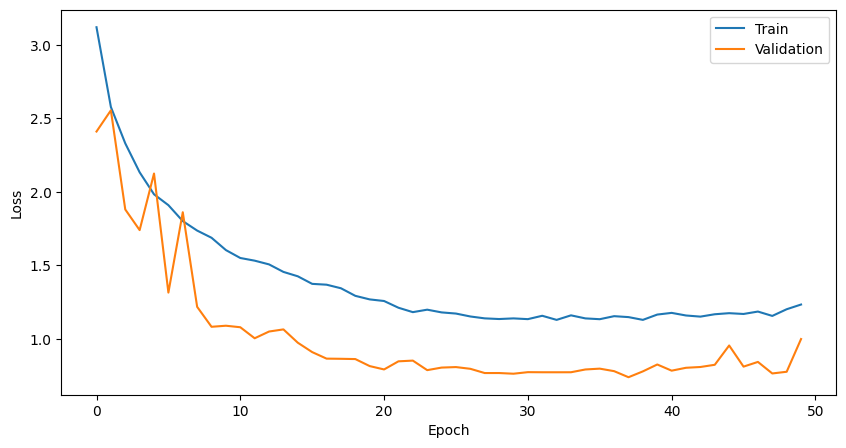

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history["train_loss"], label="Train")

plt.plot(history["val_loss"], label="Validation")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [83]:
from collections import Counter

counter = Counter()

for _, masks in train_loader:
    counter.update(masks.flatten().tolist())

print(counter)

Counter({3: 19921315, 0: 14420329, 1: 12538137, 5: 5644899, 8: 3787822, 11: 2360831, 4: 2222353, 6: 700791, 2: 678892, 7: 516960, 9: 435732, 10: 189539})


In [84]:
from collections import Counter

pred_counter = Counter()

model.eval()

with torch.no_grad():

    for images, _ in val_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1).cpu()

        pred_counter.update(preds.flatten().tolist())

print(pred_counter)

Counter({3: 4741723, 5: 3006984, 1: 2964959, 4: 1738910, 0: 1627571, 7: 1076642, 2: 541106, 11: 516189, 10: 425419, 8: 423618, 9: 271518, 6: 118161})


In [85]:
@torch.no_grad()
def evaluate_test(model, loader, device, num_classes):

    model.eval()

    metric = IoUMetric(num_classes)

    running_loss = 0
    running_acc = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        with autocast():

            outputs = model(images)
            loss = ce_loss(outputs, masks) + dice_loss(outputs, masks)

        running_loss += loss.item()
        running_acc += pixel_accuracy(outputs, masks)

        metric.update(outputs, masks)

    miou, per_class_iou = metric.compute()

    return (
        running_loss / len(loader),
        running_acc / len(loader),
        miou,
        per_class_iou
    )

In [86]:
test_loss, test_acc, test_iou, test_per_class_iou = evaluate_test(
    model,
    test_loader,
    device,
    NUM_CLASSES
)

print(f"Test Loss : {test_loss:.4f}")
print(f"Pixel Accuracy : {test_acc:.4f}")
print(f"Test mIoU : {test_iou:.4f}")

/tmp/ipykernel_9969/3792261821.py:16: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Test Loss : 1.4952
Pixel Accuracy : 0.7931
Test mIoU : 0.4897


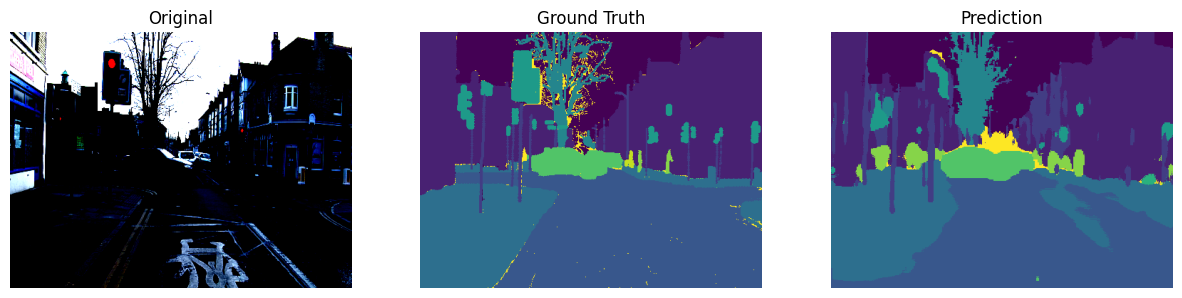

In [112]:
import matplotlib.pyplot as plt
import random

model.eval()

idx = random.randint(0, len(test_dataset)-1)

image, mask = test_dataset[idx]

with torch.no_grad():

    pred = model(image.unsqueeze(0).to(device))
    pred = pred.argmax(1).squeeze().cpu()

image = image.permute(1,2,0)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred)
plt.title("Prediction")
plt.axis("off")

plt.show()

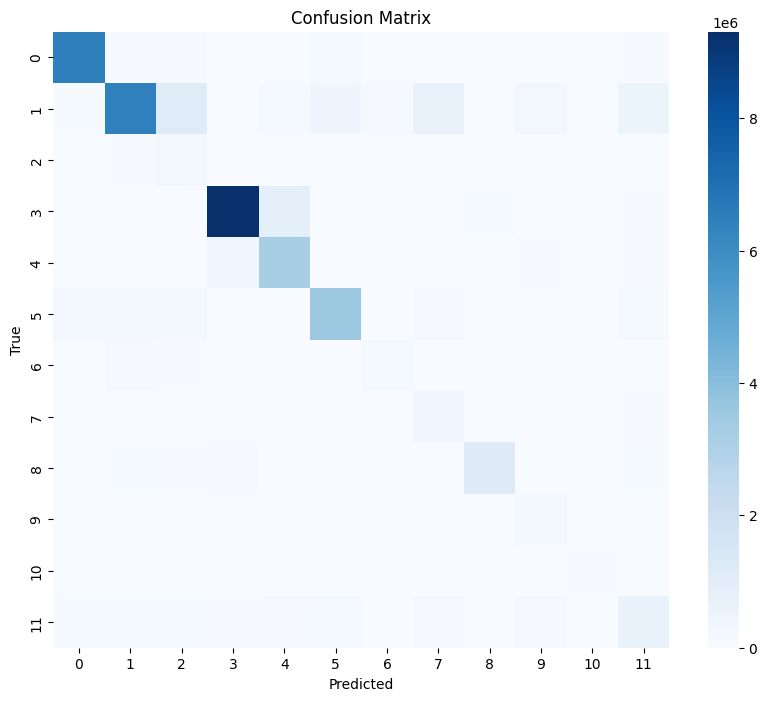

In [101]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_targets = []

model.eval()

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)

        outputs = model(images)

        preds = outputs.argmax(1).cpu()

        all_preds.extend(preds.view(-1).numpy())
        all_targets.extend(masks.view(-1).numpy())

cm = confusion_matrix(
    all_targets,
    all_preds,
    labels=list(range(NUM_CLASSES))
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    cmap="Blues",
    square=True
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

In [102]:
class_names = [
    "Sky",
    "Building",
    "Pole",
    "Road",
    "Pavement",
    "Tree",
    "Sign",
    "Fence",
    "Car",
    "Pedestrian",
    "Bicyclist",
    "Unlabelled"
]

print("-"*35)

for i in range(NUM_CLASSES):

    print(f"{class_names[i]:12s}: {test_per_class_iou[i]:.4f}")

-----------------------------------
Sky         : 0.8856
Building    : 0.6096
Pole        : 0.1375
Road        : 0.8534
Pavement    : 0.6505
Tree        : 0.6573
Sign        : 0.2758
Fence       : 0.2307
Car         : 0.6686
Pedestrian  : 0.2627
Bicyclist   : 0.3915
Unlabelled  : 0.2530


In [103]:
import pandas as pd

iou_table = pd.DataFrame({

    "Class": class_names,
    "IoU": test_per_class_iou.numpy()

})

display(iou_table)

,Class,IoU
0,Sky,0.885626
1,Building,0.609617
2,Pole,0.137491
3,Road,0.853354
4,Pavement,0.650523
5,Tree,0.657252
6,Sign,0.275803
7,Fence,0.230657
8,Car,0.668565
9,Pedestrian,0.262664
